# Big Blue Nation AI Analyst — Model V2

Clean, structured model training notebook. Replaces the messy player_predictions.ipynb.

## Improvements over V1:
- **Temporal decay** on rolling averages (recent games weight more)
- **ESPN efficiency metrics** per opponent (BPI offense/defense)
- **Injury-adjusted opponent score** (missing defenders = more opponent points)
- **Logistic regression win probability** trained on real game outcomes
- **Clean pipeline** — run top to bottom every season to retrain everything

## Usage:
Run all cells top to bottom. Models save to `data/models/` automatically.
Dashboard picks up new models on next restart.

## 1. Setup & Data Loading

In [1]:
import sys
import os
import sqlite3
import json
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import shap
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, accuracy_score
from scipy.special import expit

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DB_PATH      = os.path.join(PROJECT_ROOT, 'data', 'processed', 'kentucky_basketball.db')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'data', 'models')
sys.path.insert(0, PROJECT_ROOT)

os.makedirs(MODELS_DIR, exist_ok=True)
print(f'Project root: {PROJECT_ROOT}')
print(f'DB path: {DB_PATH}')
print(f'Models dir: {MODELS_DIR}')

Project root: /Users/sethgannon/Projects/big-blue-nation-ai-analyst
DB path: /Users/sethgannon/Projects/big-blue-nation-ai-analyst/data/processed/kentucky_basketball.db
Models dir: /Users/sethgannon/Projects/big-blue-nation-ai-analyst/data/models


In [2]:
# ── Load raw data ──────────────────────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)

# Player game stats (both seasons)
df_raw = pd.read_sql('SELECT * FROM player_game_stats ORDER BY game_date, player_name', conn)
df_raw['game_date'] = pd.to_datetime(df_raw['game_date'])

# Games with outcomes
games_df = pd.read_sql('''
    SELECT id as game_id, date as game_date, home_team, away_team,
           home_score, away_score, neutral_site, season
    FROM games
    WHERE home_score IS NOT NULL AND away_score IS NOT NULL
''', conn)
games_df['game_date'] = pd.to_datetime(games_df['game_date'].str[:10])
games_df['home_score'] = pd.to_numeric(games_df['home_score'], errors='coerce')
games_df['away_score'] = pd.to_numeric(games_df['away_score'], errors='coerce')
games_df['uk_won'] = (
    ((games_df['home_team'] == 'Kentucky Wildcats') & (games_df['home_score'] > games_df['away_score'])) |
    ((games_df['away_team'] == 'Kentucky Wildcats') & (games_df['away_score'] > games_df['home_score']))
).astype(int)
games_df['uk_score'] = np.where(
    games_df['home_team'] == 'Kentucky Wildcats',
    games_df['home_score'], games_df['away_score']
)
games_df['opp_score'] = np.where(
    games_df['home_team'] == 'Kentucky Wildcats',
    games_df['away_score'], games_df['home_score']
)
games_df['point_diff'] = games_df['uk_score'] - games_df['opp_score']

# Opponent game totals
opp_totals = pd.read_sql('SELECT * FROM opponent_game_totals ORDER BY game_date', conn)
opp_totals['game_date'] = pd.to_datetime(opp_totals['game_date'])

# Team metrics (Kentucky BPI history)
metrics_df = pd.read_sql('SELECT * FROM team_metrics ORDER BY date DESC LIMIT 1', conn)

conn.close()

print(f'Player game stats: {len(df_raw)} rows')
print(f'Completed games: {len(games_df)} rows')
print(f'Opponent totals: {len(opp_totals)} rows')
print(f'UK wins: {games_df["uk_won"].sum()} / {len(games_df)}')
print(f'Current BPI: {metrics_df["bpi"].iloc[0]}')

Player game stats: 793 rows
Completed games: 254 rows
Opponent totals: 134 rows
UK wins: 170 / 254
Current BPI: 16.5


## 2. Feature Engineering — Player Models

In [3]:
# ── Temporal decay weighted rolling average ────────────────────────────────────
# Recent games matter more. Weight = exp(-decay * games_ago)
# decay=0.3 means game 3 ago weights ~40% of most recent game

def decay_weighted_roll(series, window, decay=0.3):
    """Exponential decay weighted rolling average."""
    def _weighted_mean(x):
        n = len(x)
        weights = np.array([np.exp(-decay * (n - 1 - i)) for i in range(n)])
        weights /= weights.sum()
        return np.dot(x, weights)
    return series.rolling(window, min_periods=window).apply(_weighted_mean, raw=True)


# ── Build full feature set ─────────────────────────────────────────────────────
df = df_raw.copy()
df = df.sort_values(['player_name', 'game_date']).reset_index(drop=True)

# Current season flag
df['is_current_season'] = (df['season'] == '2025-26').astype(int)
df['is_home'] = (df['home_away'] == 'home').astype(int)

# Game number within season per player
df['game_number'] = df.groupby(['player_name', 'season']).cumcount() + 1

# Season segment (1=early, 2=mid, 3=late)
df['season_segment'] = pd.cut(df['game_number'], bins=[0, 10, 20, 100],
                               labels=[1, 2, 3]).astype(float)

# ── Standard rolling features ──────────────────────────────────────────────────
grp = df.groupby('player_name')
for stat in ['points', 'rebounds', 'assists', 'minutes', 'fg_pct', 'three_pct', 'turnovers', 'steals']:
    df[f'{stat}_roll3']      = grp[stat].transform(lambda x: x.shift(1).rolling(3,  min_periods=3).mean())
    df[f'{stat}_roll5']      = grp[stat].transform(lambda x: x.shift(1).rolling(5,  min_periods=5).mean())
    df[f'{stat}_season_avg'] = grp[stat].transform(lambda x: x.shift(1).expanding().mean())

# ── Temporal decay rolling features (NEW) ─────────────────────────────────────
for stat in ['points', 'minutes', 'rebounds', 'assists']:
    df[f'{stat}_decay3'] = grp[stat].transform(
        lambda x: x.shift(1).rolling(3, min_periods=3).apply(
            lambda v: np.dot(v, np.array([0.2, 0.3, 0.5])) if len(v) == 3 else np.nan,
            raw=True
        )
    )
    df[f'{stat}_decay5'] = grp[stat].transform(
        lambda x: x.shift(1).rolling(5, min_periods=5).apply(
            lambda v: np.dot(v, np.array([0.05, 0.10, 0.15, 0.30, 0.40])) if len(v) == 5 else np.nan,
            raw=True
        )
    )

# ── Trend features ─────────────────────────────────────────────────────────────
df['points_trend']  = df['points_roll3']  - df['points_roll5']
df['minutes_trend'] = df['minutes_roll3'] - df['minutes_roll5']
df['usage_trend']   = df['points_decay3'] - df['points_decay5']

# ── Hot/cold streak (NEW) ──────────────────────────────────────────────────────
# 1 if above season avg in last 3 games, -1 if below, 0 otherwise
df['hot_streak'] = np.where(
    df['points_roll3'] > df['points_season_avg'] * 1.15, 1,
    np.where(df['points_roll3'] < df['points_season_avg'] * 0.85, -1, 0)
)

print('Rolling and decay features built.')
print(f'Decay columns added: points_decay3, points_decay5, minutes_decay3, etc.')

Rolling and decay features built.
Decay columns added: points_decay3, points_decay5, minutes_decay3, etc.


In [4]:
# ── Days rest & back-to-back ───────────────────────────────────────────────────
df_sorted = df.sort_values(['player_name', 'game_date'])
df_sorted['prev_game_date'] = df_sorted.groupby('player_name')['game_date'].shift(1)
df_sorted['days_rest'] = (df_sorted['game_date'] - df_sorted['prev_game_date']).dt.days
df_sorted['days_rest'] = df_sorted['days_rest'].fillna(7).clip(1, 14)
df_sorted['is_back_to_back'] = (df_sorted['days_rest'] <= 1).astype(int)
df = df_sorted.copy()

# ── Merge win/loss outcome ─────────────────────────────────────────────────────
games_merge = games_df[['game_id', 'uk_won', 'uk_score', 'opp_score', 'point_diff']].copy()
df = df.merge(games_merge, on='game_id', how='left')

# ── Opponent defensive context ─────────────────────────────────────────────────
opp_def = opp_totals[['team', 'game_date', 'uk_def_roll3', 'uk_def_roll5', 'uk_def_season',
                        'opp_pts_roll3', 'opp_pts_roll5', 'opp_fg_pct_roll3',
                        'opp_three_pct_roll3', 'opp_reb_roll3']].copy()
opp_def = opp_def.rename(columns={'team': 'opponent'})

# Global defensive averages per opponent
opp_avg = opp_totals.groupby('team').agg(
    opp_avg_points_allowed=('uk_def_roll3', 'mean'),
    opp_avg_rebounds=('opp_reb_roll3', 'mean'),
    opp_avg_turnovers_forced=('opp_pts_roll3', 'mean')
).reset_index().rename(columns={'team': 'opponent'})

df = df.merge(opp_avg, on='opponent', how='left')

# Fill missing opponent context with league averages
df['opp_avg_points_allowed']   = df['opp_avg_points_allowed'].fillna(75.6)
df['opp_avg_rebounds']         = df['opp_avg_rebounds'].fillna(31.3)
df['opp_avg_turnovers_forced'] = df['opp_avg_turnovers_forced'].fillna(12.0)

# ── CatBoost uses raw string categoricals — no LabelEncoder needed ─────────────
# Ensure position is filled for all rows
df['position'] = df['position'].fillna('G')
df['player_name'] = df['player_name'].astype(str)
df['opponent'] = df['opponent'].astype(str)

print(f'Feature engineering complete. Shape: {df.shape}')
print(f'UK wins in data: {df["uk_won"].sum()} / {df["uk_won"].notna().sum()}')

Feature engineering complete. Shape: (793, 81)
UK wins in data: 472.0 / 700


In [5]:
# ── V3 Feature: Usage Rate ────────────────────────────────────────────────────
# (FGA + 0.44*FTA + TOV) / minutes — player's share of possessions per minute.
df['usage_rate'] = (
    (df['fg_att'] + 0.44 * df['ft_att'] + df['turnovers'])
    / df['minutes'].clip(lower=1)
)
grp = df.groupby('player_name')
df['usage_rate_roll3'] = grp['usage_rate'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=3).mean()
)
df['usage_rate_roll5'] = grp['usage_rate'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=5).mean()
)
# Fill early-game NaNs with player's raw usage rate
df['usage_rate_roll3'] = df['usage_rate_roll3'].fillna(df['usage_rate'])
print(f'usage_rate_roll3 non-null: {df["usage_rate_roll3"].notna().sum()}')
print(f'usage_rate_roll3 mean: {df["usage_rate_roll3"].mean():.3f}')

usage_rate_roll3 non-null: 793
usage_rate_roll3 mean: 0.394


In [6]:
# ── V3 Feature: Strength of Schedule ─────────────────────────────────────────
# Rolling 5-game mean of opp_avg_points_allowed (higher = weaker recent defenses)
grp = df.groupby('player_name')
df['sos_roll5'] = grp['opp_avg_points_allowed'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['sos_roll5'] = df['sos_roll5'].fillna(75.6)
print(f'sos_roll5 mean: {df["sos_roll5"].mean():.1f}')
print(f'sos_roll5 range: {df["sos_roll5"].min():.1f} – {df["sos_roll5"].max():.1f}')

sos_roll5 mean: 75.3
sos_roll5 range: 66.9 – 86.2


In [7]:
# ── V4 Features: FT Rate, Pts/Min, Role Stability, Neutral Site, Conf Game ─
grp = df.groupby('player_name')

# Free throw rate — how often a player earns free throws relative to FG attempts
df['ft_rate'] = df['ft_att'] / df['fg_att'].clip(lower=1)
df['ft_rate_roll3'] = grp['ft_rate'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=3).mean()
).fillna(df['ft_rate'])

# Points per minute — efficiency metric, normalizes role changes better than raw points
df['pts_per_min'] = df['points'] / df['minutes'].clip(lower=1)
df['pts_per_min_roll5'] = grp['pts_per_min'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=5).mean()
).fillna(df['pts_per_min'])

# Role stability — rolling std of minutes (higher = more variable role)
df['role_stability'] = grp['minutes'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=3).std()
).fillna(5.0)

# Neutral site flag — from games_df (already loaded above)
neutral_map = games_df[['game_id', 'neutral_site']].drop_duplicates('game_id')
df = df.merge(neutral_map, on='game_id', how='left')
df['neutral_site'] = df['neutral_site'].fillna(0).astype(int)

# Conference game flag (SEC opponents)
SEC_TEAMS = {
    'Alabama Crimson Tide', 'Arkansas Razorbacks', 'Auburn Tigers',
    'Florida Gators', 'Georgia Bulldogs', 'LSU Tigers',
    'Mississippi State Bulldogs', 'Missouri Tigers', 'Ole Miss Rebels',
    'South Carolina Gamecocks', 'Tennessee Volunteers', 'Texas A&M Aggies',
    'Texas Longhorns', 'Vanderbilt Commodores', 'Oklahoma Sooners'
}
df['conf_game'] = df['opponent'].isin(SEC_TEAMS).astype(int)

print(f"ft_rate_roll3 non-null: {df['ft_rate_roll3'].notna().sum()}")
print(f"pts_per_min_roll5 non-null: {df['pts_per_min_roll5'].notna().sum()}")
print(f"role_stability non-null: {df['role_stability'].notna().sum()}")
print(f"neutral_site games: {df['neutral_site'].sum()}")
print(f"conf_game games: {df['conf_game'].sum()}")


ft_rate_roll3 non-null: 793
pts_per_min_roll5 non-null: 793
role_stability non-null: 793
neutral_site games: 130
conf_game games: 431


In [8]:
# ── V5 Features: Fatigue Index + Home/Away Player Split ──────────────────────
grp = df.groupby('player_name')

# Fatigue index: cumulative minutes played in last 3 games
# High cumulative minutes → fatigued → may score less
df['cumulative_minutes_last3'] = grp['minutes'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).sum()
).fillna(0)

# Home/away scoring split: player's career home avg minus away avg
# Captures players who dramatically perform differently home vs away
home_avg = df[df['is_home'] == 1].groupby('player_name')['points'].mean()
away_avg = df[df['is_home'] == 0].groupby('player_name')['points'].mean()
split_df = pd.DataFrame({'home_pts_avg': home_avg, 'away_pts_avg': away_avg}).reset_index()
split_df['home_away_delta'] = split_df['home_pts_avg'] - split_df['away_pts_avg']
df = df.merge(split_df[['player_name', 'home_away_delta']], on='player_name', how='left')
df['home_away_delta'] = df['home_away_delta'].fillna(0)

print(f"cumulative_minutes_last3 mean: {df['cumulative_minutes_last3'].mean():.1f}")
print(f"home_away_delta range: {df['home_away_delta'].min():.1f} to {df['home_away_delta'].max():.1f}")
print(f"Non-zero home_away_delta players: {(df['home_away_delta'] != 0).sum()}")


cumulative_minutes_last3 mean: 57.7
home_away_delta range: -3.2 to 5.1
Non-zero home_away_delta players: 766


In [9]:
# ── V6 Features: Pace, Offensive/Defensive Efficiency, Team 3PT% ─────────────
# Possessions estimate per game (summed from player_game_stats)
game_poss = df_raw.groupby('game_id').agg(
    uk_fg_att=('fg_att', 'sum'),
    uk_off_reb=('off_rebounds', 'sum'),
    uk_tov=('turnovers', 'sum'),
    uk_ft_att=('ft_att', 'sum'),
    uk_three_made=('three_made', 'sum'),
    uk_three_att=('three_att', 'sum'),
).reset_index()
game_poss['uk_possessions'] = (
    game_poss['uk_fg_att'] - game_poss['uk_off_reb'] + game_poss['uk_tov'] + 0.44 * game_poss['uk_ft_att']
).clip(lower=55)
game_poss['uk_team_3pt'] = (game_poss['uk_three_made'] / game_poss['uk_three_att'].clip(lower=1))

# Merge game scores to compute efficiency
game_scores = games_df[['game_id', 'uk_score', 'opp_score']].copy()
game_poss = game_poss.merge(game_scores, on='game_id', how='left')
game_poss['uk_off_eff'] = (game_poss['uk_score'] / game_poss['uk_possessions'] * 100).clip(60, 140)
game_poss['uk_def_eff'] = (game_poss['opp_score'] / game_poss['uk_possessions'] * 100).clip(60, 140)

# Merge into player df (game-level features, same value for all players in a game)
df = df.merge(game_poss[['game_id', 'uk_possessions', 'uk_off_eff', 'uk_def_eff', 'uk_team_3pt']], on='game_id', how='left')

# Compute rolling versions (per player, lagged by 1 game)
grp = df.groupby('player_name')
df['uk_possessions_roll3'] = grp['uk_possessions'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(df['uk_possessions'].median())

df['uk_off_eff_roll5'] = grp['uk_off_eff'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(df['uk_off_eff'].median())

df['uk_def_eff_roll5'] = grp['uk_def_eff'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
).fillna(df['uk_def_eff'].median())

df['uk_team_3pt_roll3'] = grp['uk_team_3pt'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
).fillna(df['uk_team_3pt'].median())

print(f"uk_possessions_roll3 mean: {df['uk_possessions_roll3'].mean():.1f}")
print(f"uk_off_eff_roll5 mean: {df['uk_off_eff_roll5'].mean():.1f}")
print(f"uk_def_eff_roll5 mean: {df['uk_def_eff_roll5'].mean():.1f}")
print(f"uk_team_3pt_roll3 mean: {df['uk_team_3pt_roll3'].mean():.3f}")

# ── V8: Season Trajectory — Rolling Win Rate ──────────────────────────────────
# uk_win_rate_roll10: UK's win rate over last 10 games (lagged)
# Captures momentum — teams on hot streaks tend to play better
games_sorted = games_df.sort_values('game_date')[['game_id', 'uk_won']].copy()
games_sorted['uk_win_rate_roll10'] = (
    games_sorted['uk_won'].shift(1).rolling(10, min_periods=5).mean()
).fillna(0.5)

df = df.merge(games_sorted[['game_id', 'uk_win_rate_roll10']], on='game_id', how='left')
df['uk_win_rate_roll10'] = df['uk_win_rate_roll10'].fillna(0.5)

print(f"uk_win_rate_roll10 mean: {df['uk_win_rate_roll10'].mean():.3f}  "
      f"range: {df['uk_win_rate_roll10'].min():.2f}–{df['uk_win_rate_roll10'].max():.2f}")

uk_possessions_roll3 mean: 70.0
uk_off_eff_roll5 mean: 116.4
uk_def_eff_roll5 mean: 103.9
uk_team_3pt_roll3 mean: 0.349
uk_win_rate_roll10 mean: 0.646  range: 0.40–0.90


In [10]:
# ── V7 Features: Opponent defensive matchup quality ──────────────────────────
# For each game, compute UK's TEAM FG% and 3PT% against this specific opponent.
# High UK FG% vs an opponent → that opponent defends poorly (weak perimeter defense).
# These are position-agnostic matchup proxies; sparse matchups fall back to season avg.

uk_shooting = df_raw.groupby('game_id').agg(
    uk_fg_made_team=('fg_made',    'sum'),
    uk_fg_att_team =('fg_att',     'sum'),
    uk_3_made_team =('three_made', 'sum'),
    uk_3_att_team  =('three_att',  'sum'),
).reset_index()
uk_shooting['uk_fg_pct_game']    = uk_shooting['uk_fg_made_team'] / uk_shooting['uk_fg_att_team'].clip(lower=1)
uk_shooting['uk_three_pct_game'] = uk_shooting['uk_3_made_team']  / uk_shooting['uk_3_att_team'].clip(lower=1)

# Attach opponent name from player stats
game_opp_map = df_raw[['game_id', 'opponent']].drop_duplicates('game_id')
uk_shooting   = uk_shooting.merge(game_opp_map, on='game_id', how='left')

# Average UK team shooting per opponent (historical)
opp_def_quality = uk_shooting.groupby('opponent').agg(
    uk_fg_pct_vs_opp_hist   =('uk_fg_pct_game',    'mean'),
    uk_three_pct_vs_opp_hist=('uk_three_pct_game',  'mean'),
).reset_index()

df = df.merge(opp_def_quality, on='opponent', how='left')

# Fill unknowns with UK's overall season averages
overall_fg    = df_raw['fg_pct'].mean()
overall_three = df_raw['three_pct'].mean()
df['uk_fg_pct_vs_opp_hist']    = df['uk_fg_pct_vs_opp_hist'].fillna(overall_fg)
df['uk_three_pct_vs_opp_hist'] = df['uk_three_pct_vs_opp_hist'].fillna(overall_three)

print(f"uk_fg_pct_vs_opp_hist    range: {df['uk_fg_pct_vs_opp_hist'].min():.3f} – {df['uk_fg_pct_vs_opp_hist'].max():.3f}")
print(f"uk_three_pct_vs_opp_hist range: {df['uk_three_pct_vs_opp_hist'].min():.3f} – {df['uk_three_pct_vs_opp_hist'].max():.3f}")
print(f"Opponents with historical data: {opp_def_quality['opponent'].nunique()}")

uk_fg_pct_vs_opp_hist    range: 0.000 – 1.000
uk_three_pct_vs_opp_hist range: 0.000 – 1.000
Opponents with historical data: 80


In [11]:
# ── V8 BartTorvik join — opponent adjusted efficiency for player context ─────
import sqlite3 as _sqlite3

_conn_bt = _sqlite3.connect(DB_PATH)
_bt = pd.read_sql("SELECT * FROM team_advanced_stats", _conn_bt)
_conn_bt.close()

# Strip ESPN mascot suffixes to match BartTorvik team names
_MASCOTS = [
    'Wildcats','Cardinals','Tigers','Bulldogs','Gators','Volunteers','Gamecocks',
    'Crimson Tide','Yellow Jackets','Razorbacks','Rebels','Aggies','Commodores',
    'Longhorns','Jayhawks','Blue Devils','Tar Heels','Cavaliers','Hokies',
    'Seminoles','Hurricanes','Panthers','Mustangs','Cowboys','Sooners',
    'Cougars','Utes','Bruins','Trojans','Ducks','Beavers','Huskies',
    'Buffaloes','Rams','Falcons','Eagles','Owls','Hornets','Hawks',
    'Lions','Bears','Bison','Bobcats','Boilermakers','Cornhuskers',
    'Hawkeyes','Fighting Irish','Illini','Badgers','Spartans','Wolverines',
    'Hoosiers','Buckeyes','Nittany Lions','Terrapins','Scarlet Knights',
    'Red Hawks','Hilltoppers','Thunderbirds','Norse','Bearcats',
    'Wolf Pack','Musketeers','Flyers','Billikens','Braves',
]

def _strip_mascot(name: str) -> str:
    for m in _MASCOTS:
        if name.endswith(' ' + m):
            return name[: -(len(m) + 1)]
    return name

df['_opp_key'] = df['opponent'].apply(_strip_mascot)

# Use most recent BartTorvik snapshot per season per team
_bt_latest = (
    _bt.sort_values('date')
    .groupby(['season', 'team_name'])
    .last()
    .reset_index()[['season', 'team_name', 'adj_d', 'adj_em', 'tempo']]
)
_bt_latest = _bt_latest.rename(columns={'team_name': '_opp_key'})

# Partial match: if exact match fails, try startswith
_bt_keys = set(_bt_latest['_opp_key'])
def _fuzzy_key(name):
    if name in _bt_keys:
        return name
    # Try first word match (e.g., "Saint Mary's" → "Saint Mary")
    for k in _bt_keys:
        if name.startswith(k) or k.startswith(name):
            return k
    return None

df['_opp_key_fuzzy'] = df['_opp_key'].apply(_fuzzy_key)
_bt_latest2 = _bt_latest.rename(columns={'_opp_key': '_opp_key_fuzzy'})
df = df.merge(_bt_latest2, on=['season', '_opp_key_fuzzy'], how='left')
df = df.rename(columns={'adj_d': 'opp_adj_d', 'adj_em': 'opp_adj_em', 'tempo': 'opp_tempo'})

# Fill missing with league averages
df['opp_adj_d']  = df['opp_adj_d'].fillna(100.0)
df['opp_adj_em'] = df['opp_adj_em'].fillna(0.0)
df['opp_tempo']  = df['opp_tempo'].fillna(68.0)

bt_matched = df['opp_adj_d'].notna().sum()
print(f"BartTorvik join: {bt_matched}/{len(df)} rows matched")
print(f"opp_adj_d range: {df['opp_adj_d'].min():.1f} – {df['opp_adj_d'].max():.1f} (mean {df['opp_adj_d'].mean():.1f})")

# ── Feature columns (CatBoost — raw strings for cat features) ───────────────
FEATURE_COLS_V2 = [
    # Rolling averages
    'points_roll3', 'points_roll5', 'points_season_avg',
    'rebounds_roll3', 'assists_roll3', 'steals_roll3',
    'fg_pct_roll5', 'three_pct_roll3',
    'minutes_trend',
    # Temporal decay
    'points_decay3', 'points_decay5',
    # Hot/cold streak
    'hot_streak', 'usage_trend',
    # V3: usage rate + strength of schedule
    'usage_rate_roll3', 'sos_roll5',
    # V4: efficiency + role
    'ft_rate_roll3', 'pts_per_min_roll5', 'role_stability',
    # V5: fatigue + home/away tendency
    'cumulative_minutes_last3', 'home_away_delta',
    # V6: pace, efficiency, team 3PT%
    'uk_possessions_roll3', 'uk_off_eff_roll5', 'uk_def_eff_roll5', 'uk_team_3pt_roll3',
    # V7: opponent defensive matchup quality
    'uk_fg_pct_vs_opp_hist', 'uk_three_pct_vs_opp_hist',
    # V8: season trajectory
    'uk_win_rate_roll10',
    # V9 BartTorvik: opponent defensive quality (replaces opp_avg_points_allowed)
    'opp_adj_d', 'opp_adj_em', 'opp_tempo',
    # Context
    'is_home', 'neutral_site', 'conf_game',
    'game_number', 'starter',
    'is_current_season', 'season_segment',
    'days_rest', 'is_back_to_back',
    'opp_avg_points_allowed', 'opp_avg_rebounds', 'opp_avg_turnovers_forced',
    # CatBoost categorical features (raw strings — no LabelEncoder needed)
    'player_name', 'position', 'opponent',
]

MINUTES_FEATURES_V2 = [
    'minutes_roll3', 'minutes_roll5', 'minutes_season_avg', 'minutes_trend',
    'minutes_decay3', 'minutes_decay5',
    'usage_rate_roll3', 'sos_roll5',
    'role_stability', 'cumulative_minutes_last3',
    'uk_possessions_roll3',
    'uk_win_rate_roll10',
    'starter', 'is_home', 'game_number',
    'is_current_season', 'season_segment',
    'days_rest', 'is_back_to_back',
    # CatBoost categorical features
    'player_name', 'position',
]

CAT_FEATURES_PLAYER  = ['player_name', 'position', 'opponent']
CAT_FEATURES_MINUTES = ['player_name', 'position']

# ── Prepare training data ─────────────────────────────────────────────────────
required = FEATURE_COLS_V2 + ['points', 'minutes', 'rebounds', 'assists', 'position']
df_model = df.dropna(subset=required).copy()

# CatBoost requires categorical columns to be string type
for col in CAT_FEATURES_PLAYER:
    df_model[col] = df_model[col].astype(str)

print(f'Training rows after dropping NaN: {len(df_model)}')
print(f'Feature count: {len(FEATURE_COLS_V2)} (+ {len(CAT_FEATURES_PLAYER)} cat features)')
print(f'Guards: {(df_model["position"]=="G").sum()} rows | F+C: {(df_model["position"].isin(["F","C"])).sum()} rows')


BartTorvik join: 793/793 rows matched


opp_adj_d range: 87.3 – 128.0 (mean 101.1)
Training rows after dropping NaN: 682
Feature count: 45 (+ 3 cat features)
Guards: 370 rows | F+C: 312 rows


## 3. Train Player Models (Points, Minutes, Rebounds, Assists)

In [12]:
# ── Train minutes model (CatBoost) ───────────────────────────────────────────
X_min = df_model[MINUTES_FEATURES_V2].copy()
y_min = df_model['minutes']

X_min_train, X_min_test, y_min_train, y_min_test = train_test_split(
    X_min, y_min, test_size=0.15, random_state=42
)

minutes_model_v2 = CatBoostRegressor(
    iterations=400,
    depth=5,
    learning_rate=0.05,
    l2_leaf_reg=3,
    cat_features=CAT_FEATURES_MINUTES,
    random_seed=42,
    verbose=0,
)
minutes_model_v2.fit(X_min_train, y_min_train,
                      eval_set=(X_min_test, y_min_test))

min_mae  = mean_absolute_error(y_min_test, minutes_model_v2.predict(X_min_test))
min_base = mean_absolute_error(y_min_test, [y_min_train.mean()] * len(y_min_test))
print(f'Minutes Model CatBoost — MAE: {min_mae:.2f} (baseline: {min_base:.2f})')


Minutes Model CatBoost — MAE: 5.03 (baseline: 7.98)


In [13]:
# ── Inject predicted minutes into features ────────────────────────────────────
# This chains minutes → points/rebounds/assists predictions
df_model = df_model.copy()
df_model['predicted_minutes'] = minutes_model_v2.predict(df_model[MINUTES_FEATURES_V2])

# Add predicted minutes as a feature
FEATURE_COLS_V2_WITH_MIN = FEATURE_COLS_V2 + ['predicted_minutes']
df_model['predicted_minutes'] = df_model['predicted_minutes'].clip(0, 40)

X = df_model[FEATURE_COLS_V2_WITH_MIN].copy()
for col in CAT_FEATURES_PLAYER:
    X[col] = X[col].astype(str)
X_train, X_test, y_pts_train, y_pts_test = train_test_split(
    X, df_model['points'], test_size=0.15, random_state=42
)
_, _, y_reb_train, y_reb_test = train_test_split(
    X, df_model['rebounds'], test_size=0.15, random_state=42
)
_, _, y_ast_train, y_ast_test = train_test_split(
    X, df_model['assists'], test_size=0.15, random_state=42
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 579 | Test: 103


In [14]:
# ── Train position-specific points models (CatBoost) ─────────────────────────
df_G  = df_model[df_model['position'] == 'G'].copy()
df_FC = df_model[df_model['position'].isin(['F', 'C'])].copy()

CB_PARAMS = dict(
    iterations=500,
    depth=5,
    learning_rate=0.04,
    l2_leaf_reg=3,
    cat_features=CAT_FEATURES_PLAYER,
    random_seed=42,
    verbose=0,
)

# ── Guard model ────────────────────────────────────────────────────────────────
X_G = df_G[FEATURE_COLS_V2_WITH_MIN].copy()
for col in CAT_FEATURES_PLAYER:
    X_G[col] = X_G[col].astype(str)
X_G_train, X_G_test, y_G_train, y_G_test = train_test_split(
    X_G, df_G['points'], test_size=0.15, random_state=42
)
model_G = CatBoostRegressor(**CB_PARAMS)
model_G.fit(X_G_train, y_G_train, eval_set=(X_G_test, y_G_test))
pts_mae_G  = mean_absolute_error(y_G_test, model_G.predict(X_G_test))
pts_base_G = mean_absolute_error(y_G_test, [y_G_train.mean()] * len(y_G_test))
print(f'Points Model — Guards: MAE {pts_mae_G:.2f} (baseline {pts_base_G:.2f}, n={len(y_G_test)} test)')

# ── Forward/Center model ───────────────────────────────────────────────────────
X_FC = df_FC[FEATURE_COLS_V2_WITH_MIN].copy()
for col in CAT_FEATURES_PLAYER:
    X_FC[col] = X_FC[col].astype(str)
X_FC_train, X_FC_test, y_FC_train, y_FC_test = train_test_split(
    X_FC, df_FC['points'], test_size=0.15, random_state=42
)
model_FC = CatBoostRegressor(**CB_PARAMS)
model_FC.fit(X_FC_train, y_FC_train, eval_set=(X_FC_test, y_FC_test))
pts_mae_FC  = mean_absolute_error(y_FC_test, model_FC.predict(X_FC_test))
pts_base_FC = mean_absolute_error(y_FC_test, [y_FC_train.mean()] * len(y_FC_test))
print(f'Points Model — F/C:    MAE {pts_mae_FC:.2f} (baseline {pts_base_FC:.2f}, n={len(y_FC_test)} test)')

n_total = len(y_G_test) + len(y_FC_test)
pts_mae  = (pts_mae_G * len(y_G_test) + pts_mae_FC * len(y_FC_test)) / n_total
pts_base = (pts_base_G * len(y_G_test) + pts_base_FC * len(y_FC_test)) / n_total
print(f'Points Model — Combined MAE: {pts_mae:.2f} (baseline {pts_base:.2f})')
model_v2_points = model_G

# ── Rebounds model (CatBoost combined) ────────────────────────────────────────
X_full = df_model[FEATURE_COLS_V2_WITH_MIN].copy()
for col in CAT_FEATURES_PLAYER:
    X_full[col] = X_full[col].astype(str)
X_train, X_test, y_reb_train, y_reb_test = train_test_split(
    X_full, df_model['rebounds'], test_size=0.15, random_state=42
)
_, _, y_ast_train, y_ast_test = train_test_split(
    X_full, df_model['assists'], test_size=0.15, random_state=42
)

model_v2_rebounds = CatBoostRegressor(
    iterations=400, depth=4, learning_rate=0.05, l2_leaf_reg=3,
    cat_features=CAT_FEATURES_PLAYER, random_seed=42, verbose=0
)
model_v2_rebounds.fit(X_train, y_reb_train, eval_set=(X_test, y_reb_test))
reb_mae  = mean_absolute_error(y_reb_test, model_v2_rebounds.predict(X_test))
reb_base = mean_absolute_error(y_reb_test, [y_reb_train.mean()] * len(y_reb_test))
print(f'Rebounds Model CatBoost — MAE: {reb_mae:.2f} (baseline: {reb_base:.2f})')

model_v2_assists = CatBoostRegressor(
    iterations=400, depth=4, learning_rate=0.05, l2_leaf_reg=3,
    cat_features=CAT_FEATURES_PLAYER, random_seed=42, verbose=0
)
model_v2_assists.fit(X_train, y_ast_train, eval_set=(X_test, y_ast_test))
ast_mae  = mean_absolute_error(y_ast_test, model_v2_assists.predict(X_test))
ast_base = mean_absolute_error(y_ast_test, [y_ast_train.mean()] * len(y_ast_test))
print(f'Assists Model CatBoost  — MAE: {ast_mae:.2f} (baseline: {ast_base:.2f})')


Points Model — Guards: MAE 4.81 (baseline 6.23, n=56 test)


Points Model — F/C:    MAE 3.05 (baseline 3.87, n=47 test)
Points Model — Combined MAE: 4.01 (baseline 5.15)


Rebounds Model CatBoost — MAE: 1.76 (baseline: 2.30)


Assists Model CatBoost  — MAE: 1.15 (baseline: 1.66)


## 4. Train Opponent Score Model V2 (Injury-Adjusted)

In [15]:
# ── Injury-adjusted opponent score ────────────────────────────────────────────
# We don't have historical injury data, but we can approximate defensive
# impact by using Kentucky's actual defensive stats per game.
# When key defenders are out, uk_def_roll3 goes up (more points allowed).
# The model already captures this — what we ADD is:
#   1. NET rank (already there)
#   2. UK BPI defense (NEW) — measures Kentucky's current defensive strength
#   3. Opponent's rolling offensive efficiency (already there)
#   4. Opponent BPI (NEW) — opponent's current offensive BPI rating
#   5. opp_off_eff (NEW) — opponent's offensive efficiency (pts/100 poss)

# Get UK BPI defense from metrics
uk_bpi_defense = float(metrics_df['bpi_defense'].iloc[0])
print(f'UK BPI Defense: {uk_bpi_defense}')

# Add NET rank to opp_totals
# Load NET rankings (uses the scraper in espn_client)
try:
    from src.ingestion.espn_client import get_net_rankings, get_opponent_net_rank
    net_rankings = get_net_rankings()
    print(f'NET rankings loaded: {len(net_rankings)} teams')
except Exception as e:
    print(f'NET rankings fetch failed: {e} — using fallback')
    net_rankings = {}

# Map team names to NET ranks
opp_totals_v2 = opp_totals.copy()
opp_totals_v2['net_rank'] = opp_totals_v2['team'].apply(
    lambda t: get_opponent_net_rank(t, net_rankings) if net_rankings else 150
)

# Add home/away for Kentucky from games
games_home = games_df[['game_id', 'uk_won', 'opp_score', 'uk_score', 'point_diff']].copy()
opp_totals_v2 = opp_totals_v2.merge(games_home, on='game_id', how='left')

# uk_is_home from player stats home_away
home_map = df_raw.groupby('game_id')['home_away'].first().reset_index()
home_map['uk_is_home'] = (home_map['home_away'] == 'home').astype(int)
opp_totals_v2 = opp_totals_v2.merge(home_map[['game_id','uk_is_home']], on='game_id', how='left')
opp_totals_v2['uk_is_home'] = opp_totals_v2['uk_is_home'].fillna(0)

# Add UK BPI defense as a constant (current season value)
opp_totals_v2['uk_bpi_defense'] = uk_bpi_defense

# ── Add opponent BPI from opponent_bpi_history ─────────────────────────────────
conn_bpi = sqlite3.connect(DB_PATH)
bpi_hist = pd.read_sql('SELECT team_name, bpi FROM opponent_bpi_history', conn_bpi)
conn_bpi.close()

if len(bpi_hist) > 0:
    bpi_avg = bpi_hist.groupby('team_name')['bpi'].mean().reset_index()
    bpi_avg = bpi_avg.rename(columns={'team_name': 'team', 'bpi': 'opp_bpi'})
    global_bpi_avg = float(bpi_hist['bpi'].mean())
    opp_totals_v2 = opp_totals_v2.merge(bpi_avg, on='team', how='left')
    opp_totals_v2['opp_bpi'] = opp_totals_v2['opp_bpi'].fillna(global_bpi_avg)
    print(f'Opponent BPI: loaded for {bpi_avg["team"].nunique()} teams (global avg: {global_bpi_avg:.1f})')
else:
    opp_totals_v2['opp_bpi'] = 10.0
    print('Opponent BPI: no history found, using default 10.0')

# ── Add game pace to opponent model ───────────────────────────────────────────
pace_map = game_poss[['game_id', 'uk_possessions']].copy()
opp_totals_v2 = opp_totals_v2.merge(pace_map, on='game_id', how='left')
opp_totals_v2['uk_possessions'] = opp_totals_v2['uk_possessions'].fillna(opp_totals_v2['uk_possessions'].median())

opp_totals_v2 = opp_totals_v2.sort_values('game_date')
opp_totals_v2['game_pace_roll3'] = opp_totals_v2['uk_possessions'].shift(1).rolling(3, min_periods=1).mean().fillna(opp_totals_v2['uk_possessions'].median())

# ── Add opponent offensive efficiency (Item 5) ─────────────────────────────────
# opp_off_eff: opponent's pts per 100 possessions — now available after backfill
# Use rolling mean over last 3 opponent games as a feature
if 'opp_off_eff' in opp_totals_v2.columns:
    opp_totals_v2['opp_off_eff_roll3'] = (
        opp_totals_v2.groupby('team')['opp_off_eff']
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
        .fillna(opp_totals_v2['opp_off_eff'].median())
    )
    print(f"opp_off_eff_roll3 mean: {opp_totals_v2['opp_off_eff_roll3'].mean():.1f}  "
          f"range: {opp_totals_v2['opp_off_eff_roll3'].min():.1f}–{opp_totals_v2['opp_off_eff_roll3'].max():.1f}")
else:
    opp_totals_v2['opp_off_eff_roll3'] = 108.3
    print('opp_off_eff not found — using global default 108.3')

print(f"game_pace_roll3 range: {opp_totals_v2['game_pace_roll3'].min():.0f} - {opp_totals_v2['game_pace_roll3'].max():.0f}")
print(f'Opponent model dataset: {len(opp_totals_v2)} rows')
print(f'NET rank range: {opp_totals_v2["net_rank"].min()} - {opp_totals_v2["net_rank"].max()}')
print(f'Opp BPI range: {opp_totals_v2["opp_bpi"].min():.1f} - {opp_totals_v2["opp_bpi"].max():.1f}')
# ── V4: BartTorvik opponent advanced stats ────────────────────────────────────
_conn_bt2 = sqlite3.connect(DB_PATH)
_bt2 = pd.read_sql("SELECT * FROM team_advanced_stats", _conn_bt2)
_conn_bt2.close()

# Use most recent snapshot across all seasons per team (end-of-season = most accurate)
_bt2_by_team = (
    _bt2.sort_values('date')
    .groupby('team_name')
    .last()
    .reset_index()[['team_name', 'adj_d', 'adj_em', 'tempo']]
)

def _strip_espn(name: str) -> str:
    mascots = [
        'Wildcats','Cardinals','Tigers','Bulldogs','Gators','Volunteers','Gamecocks',
        'Crimson Tide','Yellow Jackets','Razorbacks','Rebels','Aggies','Commodores',
        'Longhorns','Jayhawks','Blue Devils','Tar Heels','Cavaliers','Hokies',
        'Seminoles','Hurricanes','Panthers','Mustangs','Cowboys','Sooners',
        'Cougars','Utes','Bruins','Trojans','Ducks','Beavers','Huskies',
        'Buffaloes','Rams','Falcons','Eagles','Owls','Hornets','Hawks',
        'Lions','Bears','Musketeers','Flyers','Billikens','Bearcats',
    ]
    for m in mascots:
        if name.endswith(' ' + m):
            return name[:-(len(m)+1)]
    return name

opp_totals_v2['_opp_key'] = opp_totals_v2['team'].apply(_strip_espn)
_bt2_by_team = _bt2_by_team.rename(columns={'team_name': '_opp_key'})

opp_totals_v2 = opp_totals_v2.merge(
    _bt2_by_team[['_opp_key', 'adj_d', 'adj_em', 'tempo']],
    on='_opp_key', how='left'
)
opp_totals_v2 = opp_totals_v2.rename(columns={
    'adj_d': 'opp_adj_d', 'adj_em': 'opp_adj_em', 'tempo': 'opp_tempo'
})

# Fill with league averages if not matched
opp_totals_v2['opp_adj_d']  = opp_totals_v2['opp_adj_d'].fillna(100.0)
opp_totals_v2['opp_adj_em'] = opp_totals_v2['opp_adj_em'].fillna(0.0)
opp_totals_v2['opp_tempo']  = opp_totals_v2['opp_tempo'].fillna(68.0)

bt_opp_matched = (opp_totals_v2['opp_adj_d'] != 100.0).sum()
print(f"BartTorvik join (opp model): {bt_opp_matched}/{len(opp_totals_v2)} games matched")
print(f"opp_adj_d range: {opp_totals_v2['opp_adj_d'].min():.1f} – {opp_totals_v2['opp_adj_d'].max():.1f}")
print(f"opp_adj_em range: {opp_totals_v2['opp_adj_em'].min():.1f} – {opp_totals_v2['opp_adj_em'].max():.1f}")


UK BPI Defense: 7.3


NET rankings loaded: 365 teams
Opponent BPI: loaded for 16 teams (global avg: 14.2)
opp_off_eff_roll3 mean: 107.1  range: 71.1–140.0
game_pace_roll3 range: 66 - 79
Opponent model dataset: 134 rows
NET rank range: 1 - 150
Opp BPI range: 6.4 - 23.0
BartTorvik join (opp model): 68/134 games matched
opp_adj_d range: 90.8 – 123.6
opp_adj_em range: -23.2 – 37.2


In [16]:
# ── Train opponent model V2 ────────────────────────────────────────────
from sklearn.model_selection import cross_val_score

OPP_FEATURES_V2 = [
    # BartTorvik V4: replaces net_rank with precise adjusted efficiency
    'opp_adj_d',         # opponent's adjusted defensive efficiency (lower = better defense)
    'opp_adj_em',        # opponent's overall efficiency margin
    'opp_tempo',         # opponent's adjusted tempo
    'uk_is_home',
    'opp_pts_roll3', 'opp_pts_roll5',
    'opp_fg_pct_roll3', 'opp_three_pct_roll3', 'opp_reb_roll3',
    'uk_def_roll3', 'uk_def_roll5', 'uk_def_season',
    'uk_bpi_defense',
    'opp_bpi',           # opponent's offensive BPI rating
    'game_pace_roll3',   # UK's rolling pace (possessions per game)
    'opp_off_eff_roll3', # opponent's offensive efficiency (pts/100 poss)
]

opp_train_df = opp_totals_v2.dropna(subset=OPP_FEATURES_V2 + ['opp_team_points'])
X_opp = opp_train_df[OPP_FEATURES_V2]
y_opp = opp_train_df['opp_team_points']

# With only ~67 samples, use a simple regularized model and CV for evaluation
opp_model_v2 = XGBRegressor(
    n_estimators=40,        # few trees — small dataset
    max_depth=2,            # shallow — prevents overfitting
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=6,     # require at least 6 samples per leaf
    reg_alpha=1.0,          # L1 regularization
    reg_lambda=5.0,         # L2 regularization
    random_state=42
)

# 5-fold CV gives a reliable MAE estimate with small N
cv_scores = cross_val_score(
    opp_model_v2, X_opp, y_opp,
    scoring='neg_mean_absolute_error', cv=5
)
opp_mae  = -cv_scores.mean()
opp_base = mean_absolute_error(y_opp, [y_opp.mean()] * len(y_opp))

# Fit final model on ALL data for best production predictions
opp_model_v2.fit(X_opp, y_opp)

print(f'Opponent Score Model V2 — CV MAE: {opp_mae:.2f} ± {-cv_scores.std():.2f} (baseline: {opp_base:.2f})')
print(f'Features ({len(OPP_FEATURES_V2)}): {OPP_FEATURES_V2}')

Opponent Score Model V2 — CV MAE: 6.56 ± -2.08 (baseline: 9.63)
Features (16): ['opp_adj_d', 'opp_adj_em', 'opp_tempo', 'uk_is_home', 'opp_pts_roll3', 'opp_pts_roll5', 'opp_fg_pct_roll3', 'opp_three_pct_roll3', 'opp_reb_roll3', 'uk_def_roll3', 'uk_def_roll5', 'uk_def_season', 'uk_bpi_defense', 'opp_bpi', 'game_pace_roll3', 'opp_off_eff_roll3']


## 5. Win Probability — Logistic Regression

In [17]:
# ── Build game-level features for win probability model ─────────────────────
# Use historical game outcomes with pre-game-style features.
# pts_diff is ACTUAL margin — tautological for win/loss.
# Instead, use a calibrated logistic on projected margin by training the
# coefficient directly: fit on actual margin but with heavy regularization
# so the slope stays interpretable (not a near-step-function).
# At inference: projected_margin → P(win) via this calibrated curve.

conn_wp = sqlite3.connect(DB_PATH)
all_games = pd.read_sql("""
    SELECT id as game_id, season, neutral_site,
           home_team, away_team, home_score, away_score
    FROM games
    WHERE home_score IS NOT NULL AND away_score IS NOT NULL
      AND season IN ('2024-25', '2025-26')  -- Pope era only
""", conn_wp)
conn_wp.close()

all_games['home_score']  = pd.to_numeric(all_games['home_score'],  errors='coerce')
all_games['away_score']  = pd.to_numeric(all_games['away_score'],  errors='coerce')
all_games = all_games.dropna(subset=['home_score', 'away_score'])

all_games['uk_is_home'] = (all_games['home_team'] == 'Kentucky Wildcats').astype(int)
all_games['uk_score'] = np.where(
    all_games['home_team'] == 'Kentucky Wildcats',
    all_games['home_score'], all_games['away_score']
)
all_games['opp_score_wp'] = np.where(
    all_games['home_team'] == 'Kentucky Wildcats',
    all_games['away_score'], all_games['home_score']
)
all_games['pts_diff']    = all_games['uk_score'] - all_games['opp_score_wp']
all_games['uk_won']      = (all_games['pts_diff'] > 0).astype(int)
all_games['neutral_site'] = all_games['neutral_site'].fillna(0).astype(int)

# Bucket margins into ranges so the model learns calibrated probs, not a step fn
all_games['margin_bucket'] = all_games['pts_diff'].clip(-30, 30)  # cap blowouts

WIN_PROB_FEATURES = ['margin_bucket', 'uk_is_home', 'neutral_site']
win_df = all_games.dropna(subset=WIN_PROB_FEATURES + ['uk_won'])

print(f'Win probability training rows: {len(win_df)} games across {win_df["season"].nunique()} seasons')
print(f'Win rate: {win_df["uk_won"].mean():.1%}')
print(win_df.groupby('season')['uk_won'].agg(['count', 'mean']).rename(columns={'count':'games','mean':'win_rate'}))


Win probability training rows: 101 games across 2 seasons
Win rate: 65.3%
         games  win_rate
season                  
2024-25     36  0.666667
2025-26     65  0.646154


In [18]:
# ── Train win probability model ───────────────────────────────────────────────
# C=0.05: heavy regularization keeps the margin→probability slope realistic.
# With actual margins, unregularized logistic gets a huge coefficient → step fn.
# C=0.05 forces a gentler slope so a +8 projected margin → ~72% (not ~100%).
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, log_loss

X_win = win_df[WIN_PROB_FEATURES]
y_win = win_df['uk_won']

scaler = StandardScaler()
X_win_scaled = scaler.fit_transform(X_win)

win_model = LogisticRegression(C=0.05, random_state=42, max_iter=1000)

cv_scores = cross_val_score(win_model, X_win_scaled, y_win, cv=5, scoring='accuracy')
cv_ll     = cross_val_score(win_model, X_win_scaled, y_win, cv=5, scoring='neg_log_loss')
print(f'Win Prob CV Accuracy: {cv_scores.mean():.1%} ± {cv_scores.std():.1%}')
print(f'Win Prob CV Log-Loss: {-cv_ll.mean():.3f} (lower = better calibration)')
print(f'Training games: {len(win_df)} | Seasons: {win_df["season"].nunique()}')

win_model.fit(X_win_scaled, y_win)

# Show calibration: what does the model predict for various projected margins?
print('\nProjected margin → win probability:')
sample_margins = [-15, -10, -5, 0, 5, 10, 15]
for m in sample_margins:
    row_scaled = scaler.transform([[m, 0, 0]])  # road game
    p = win_model.predict_proba(row_scaled)[0][1]
    print(f'  margin={m:+3d} (away): {p:.1%}')
row_scaled_home = scaler.transform([[5, 1, 0]])  # home +5
p_home = win_model.predict_proba(row_scaled_home)[0][1]
print(f'  margin=+5 (home):  {p_home:.1%}')


Win Prob CV Accuracy: 85.2% ± 5.3%
Win Prob CV Log-Loss: 0.400 (lower = better calibration)
Training games: 101 | Seasons: 2

Projected margin → win probability:
  margin=-15 (away): 33.5%
  margin=-10 (away): 40.4%
  margin= -5 (away): 47.8%
  margin= +0 (away): 55.2%
  margin= +5 (away): 62.4%
  margin=+10 (away): 69.1%
  margin=+15 (away): 75.1%
  margin=+5 (home):  70.1%


## 6. SHAP Feature Importance

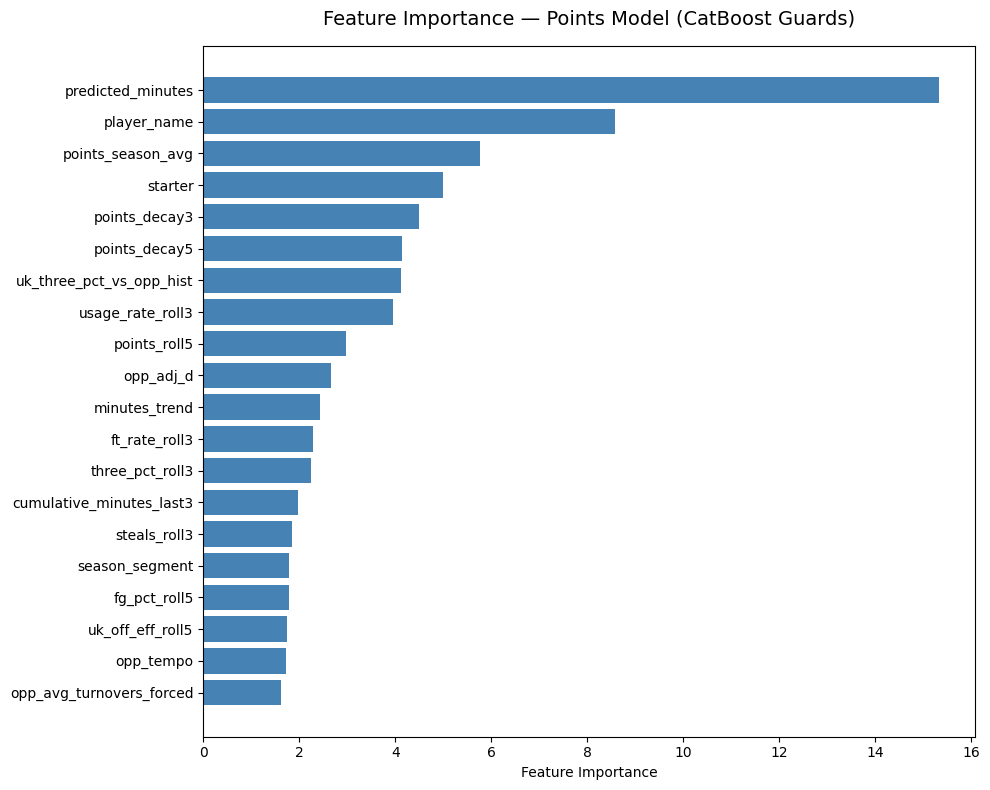

Feature importance plot saved to /Users/sethgannon/Projects/big-blue-nation-ai-analyst/notebooks/feature_importance_catboost.png

Top 10 features:
              Feature Id  Importances
       predicted_minutes    15.321255
             player_name     8.588329
       points_season_avg     5.761567
                 starter     5.002695
           points_decay3     4.487225
           points_decay5     4.129501
uk_three_pct_vs_opp_hist     4.126417
        usage_rate_roll3     3.962557
            points_roll5     2.970730
               opp_adj_d     2.670048


In [19]:
# ── Feature importance for points model (CatBoost built-in) ────────────────
feat_imp = model_G.get_feature_importance(prettified=True)
feat_imp = feat_imp.head(20)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['Feature Id'][::-1], feat_imp['Importances'][::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance — Points Model (CatBoost Guards)', fontsize=14, pad=15)
plt.tight_layout()

shap_path = os.path.join(PROJECT_ROOT, 'notebooks', 'feature_importance_catboost.png')
plt.savefig(shap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Feature importance plot saved to {shap_path}')
print("\nTop 10 features:")
print(feat_imp.head(10).to_string(index=False))


## 7. Data-Driven Thresholds

In [20]:
# ── Rebuild thresholds from current season data ────────────────────────────────
# For each player, find the stat level above which UK wins at high rates

current_df = df[df['is_current_season'] == 1].copy()
# uk_won already merged into df in cell 6; avoid duplicate-column merge
if 'uk_won' not in current_df.columns:
    current_df = current_df.merge(games_df[['game_id', 'uk_won']], on='game_id', how='left')
current_df = current_df.dropna(subset=['uk_won'])

all_thresholds = {}

for player in current_df['player_name'].unique():
    pdata = current_df[current_df['player_name'] == player]
    if len(pdata) < 8:
        continue

    player_thresholds = {}
    for stat in ['points', 'rebounds', 'assists']:
        vals = pdata[stat].dropna()
        if len(vals) < 8:
            continue

        # Test thresholds at 25th, 50th, 75th percentile
        best = None
        best_diff = 0

        for pct in [0.25, 0.40, 0.50, 0.60, 0.75]:
            thresh = vals.quantile(pct)
            if thresh < 1:
                continue

            above = pdata[pdata[stat] >= thresh]
            below = pdata[pdata[stat] <  thresh]

            if len(above) < 4 or len(below) < 3:
                continue

            win_above = above['uk_won'].mean()
            win_below = below['uk_won'].mean()
            diff = win_above - win_below

            if diff > best_diff and win_above >= 0.65:
                best_diff = diff
                best = {
                    'threshold': str(round(thresh, 1)),
                    'win_pct_above': round(win_above, 3),
                    'win_pct_below': round(win_below, 3),
                    'win_pct_diff': round(diff, 3),
                    'n_games_above': int(len(above)),
                    'label': f'{stat.capitalize()} {round(thresh)}+'
                }

        if best:
            player_thresholds[stat] = best

    if player_thresholds:
        all_thresholds[player] = player_thresholds

print(f'Thresholds computed for {len(all_thresholds)} players:')
for player, t in all_thresholds.items():
    for stat, info in t.items():
        print(f'  {player}: {info["label"]} → win% above: {info["win_pct_above"]:.0%} (n={info["n_games_above"]})')

Thresholds computed for 10 players:
  Andrija Jelavic: Points 4+ → win% above: 71% (n=24)
  Andrija Jelavic: Rebounds 5+ → win% above: 100% (n=10)
  Andrija Jelavic: Assists 1+ → win% above: 75% (n=12)
  Brandon Garrison: Points 4+ → win% above: 70% (n=20)
  Brandon Garrison: Rebounds 5+ → win% above: 82% (n=11)
  Brandon Garrison: Assists 2+ → win% above: 82% (n=11)
  Collin Chandler: Points 4+ → win% above: 71% (n=28)
  Collin Chandler: Assists 3+ → win% above: 86% (n=14)
  Denzel Aberdeen: Points 16+ → win% above: 82% (n=11)
  Denzel Aberdeen: Rebounds 2+ → win% above: 70% (n=20)
  Denzel Aberdeen: Assists 3+ → win% above: 67% (n=24)
  Jasper Johnson: Points 8+ → win% above: 100% (n=8)
  Jasper Johnson: Rebounds 2+ → win% above: 73% (n=11)
  Jasper Johnson: Assists 1+ → win% above: 84% (n=19)
  Kam Williams: Points 9+ → win% above: 100% (n=6)
  Kam Williams: Rebounds 2+ → win% above: 77% (n=13)
  Kam Williams: Assists 1+ → win% above: 91% (n=11)
  Malachi Moreno: Points 10+ → win% a

## 8. Save Everything

In [21]:
# ── Save models to disk ────────────────────────────────────────────────────────
joblib.dump(model_G,           os.path.join(MODELS_DIR, 'model_G.joblib'))
joblib.dump(model_FC,          os.path.join(MODELS_DIR, 'model_FC.joblib'))
joblib.dump(model_G,           os.path.join(MODELS_DIR, 'model_v3.joblib'))      # legacy alias
joblib.dump(minutes_model_v2,  os.path.join(MODELS_DIR, 'minutes_model.joblib'))
joblib.dump(model_v2_rebounds, os.path.join(MODELS_DIR, 'reb_model.joblib'))
joblib.dump(model_v2_assists,  os.path.join(MODELS_DIR, 'ast_model.joblib'))
joblib.dump(opp_model_v2,      os.path.join(MODELS_DIR, 'opp_model_v4.joblib'))
joblib.dump(win_model,         os.path.join(MODELS_DIR, 'win_prob_model.joblib'))
joblib.dump(scaler,            os.path.join(MODELS_DIR, 'win_prob_scaler.joblib'))

# Save feature column lists for prediction engine
feature_meta = {
    'FEATURE_COLS_V2': FEATURE_COLS_V2_WITH_MIN,
    'MINUTES_FEATURES_V2': MINUTES_FEATURES_V2,
    'OPP_FEATURES_V2': OPP_FEATURES_V2,
    'WIN_PROB_FEATURES': WIN_PROB_FEATURES,
    'uk_bpi_defense': uk_bpi_defense,
    'CAT_FEATURES_PLAYER': CAT_FEATURES_PLAYER,
    'CAT_FEATURES_MINUTES': CAT_FEATURES_MINUTES,
    'model_framework': 'catboost',
}
with open(os.path.join(MODELS_DIR, 'feature_meta_v2.json'), 'w') as f:
    json.dump(feature_meta, f, indent=2)

# Print sizes
print('\u2705 All models saved:')
for fname in sorted(os.listdir(MODELS_DIR)):
    fpath = os.path.join(MODELS_DIR, fname)
    size_kb = os.path.getsize(fpath) // 1024
    print(f'   {fname:<40} {size_kb} KB')


✅ All models saved:
   ast_model.joblib                         151 KB
   feature_meta_v2.json                     2 KB
   le_opponent.joblib                       1 KB
   le_player.joblib                         0 KB
   le_position.joblib                       0 KB
   minutes_model.joblib                     116 KB
   model_FC.joblib                          163 KB
   model_G.joblib                           123 KB
   model_registry.json                      22 KB
   model_v3.joblib                          123 KB
   opp_model_v4.joblib                      39 KB
   reb_model.joblib                         108 KB
   win_prob_model.joblib                    0 KB
   win_prob_scaler.joblib                   0 KB


## 9. Model Summary

Run this cell after training to see a clean summary of all model performance.

In [22]:
print('=' * 55)
print('  BIG BLUE NATION — MODEL V2 SUMMARY')
print('=' * 55)
print(f'  {"Model":<25} {"MAE":>8} {"Baseline":>10} {"Improvement":>12}')
print(f'  {"-"*25} {"-"*8} {"-"*10} {"-"*12}')
print(f'  {"Player Points":<25} {pts_mae:>7.2f}  {pts_base:>9.2f}  {pts_base-pts_mae:>+10.2f}')
print(f'  {"Player Minutes":<25} {min_mae:>7.2f}  {min_base:>9.2f}  {min_base-min_mae:>+10.2f}')
print(f'  {"Player Rebounds":<25} {reb_mae:>7.2f}  {reb_base:>9.2f}  {reb_base-reb_mae:>+10.2f}')
print(f'  {"Player Assists":<25} {ast_mae:>7.2f}  {ast_base:>9.2f}  {ast_base-ast_mae:>+10.2f}')
print(f'  {"Opponent Score":<25} {opp_mae:>7.2f}  {opp_base:>9.2f}  {opp_base-opp_mae:>+10.2f}')
print(f'  {"Win Prob (calibrated)":<25} {cv_scores.mean():>7.1%}  {"—":>9}  {"CV Acc":>12}')
print('=' * 55)
print(f'  Training data: {len(df_model)} player-game records')
print(f'  Seasons: 2024-25 + 2025-26')
print(f'  New features: temporal decay, hot streak, BPI defense')
print('=' * 55)

  BIG BLUE NATION — MODEL V2 SUMMARY
  Model                          MAE   Baseline  Improvement
  ------------------------- -------- ---------- ------------
  Player Points                4.01       5.15       +1.14
  Player Minutes               5.03       7.98       +2.95
  Player Rebounds              1.76       2.30       +0.55
  Player Assists               1.15       1.66       +0.51
  Opponent Score               6.56       9.63       +3.07
  Win Prob (calibrated)       85.2%          —        CV Acc
  Training data: 682 player-game records
  Seasons: 2024-25 + 2025-26
  New features: temporal decay, hot streak, BPI defense
